In [1]:
# моделирование линейной системы
# взаимодействующих друг с другом
# магнитных спинов

# Ячейка № 1

# подключение библиотеки numpy
import numpy as np

# подключение генератора случайных чисел
import random

# подключение пакета matplotlib.pyplot
import matplotlib.pyplot as plt

# подключение инструментария
# для построения 3D графиков

# импорт из библиотеки scipy.optimize
# функции curve_fit
from scipy.optimize import curve_fit

In [ ]:
# Ячейка № 2

# задание функции, возвращающей мгновенные значения:
# полной энергии системы;
# энергии Демона;
# суммарного магнитного момента
# моделируемой системы
def Ising_2D(N_x, N_y, J, h, E_finish, N_Trial):
    # N_x, N_y  - узлов координатной сетки по соответствующим осям
    # J - константа обменного взаимодействия
    # h - внешнее магнитное поле
    # E_Finish - конечная энергия системы
    # N_Trial - число независимых испытаний в методе Монте-Карло

    s = np.zeros([N_y, N_x, N_Trial + 1])
    # число спинов моделируемой системы
    N_Spin = N_x * N_y

    # инициализация начальной конфигурации спинов
    S = np.ones([N_y, N_x])

    s[:, :, 0] = S[:, :]
    # вычисление начального значения энергии системы
    E_System_Test = int(-(J + h) * N_Spin)

    # вычисление начального значения энергии демона
    E_Demon_Test = 4 * J * int((E_finish - E_System_Test) / (4 * J))

    # инициализация массивов, используемых
    # для хранения мгновенных значений:
    # полной энергии системы (E_System);
    # энергии демона (E_Demon);
    # суммарного магнитного момента
    # моделируемой системы (Summry_Spin_Moment)
    E_System = np.zeros(N_Trial + 1, dtype="int")
    E_Demon = np.zeros(N_Trial + 1, dtype="int")
    Summary_Spin_Moment = np.zeros(N_Trial + 1, dtype="int")
    Accept = np.zeros(N_Trial + 1)

    # сохранение начальных значений
    # полной энергии системы;
    # энергии демона;
    # суммарного магнитного момента
    # моделируемой системы (Summry_Spin_Moment)
    E_System[0] = E_System_Test
    E_Demon[0] = E_Demon_Test
    Summary_Spin_Moment[0] = N_Spin

    # реализация метода микроканонического ансамбля
    k = 0

    for i in range(1, N_Trial + 1):
        # подсчитываем число принятых
        # пробных переворотов спинов
        # на каждом шаге метода Монте-Карло
        N_Accept = 0
        for j in range(N_Spin):
            # случайный выбор координат переворачиваемого спина
            I_x = int(random.uniform(0, N_x))
            I_y = int(random.uniform(0, N_y))
            # выбираем номера соседних
            # с переворачиваемым спином
            #  с учетом периодических граничных условий
            if I_x == 0:
                Left = N_x - 1
                Right = I_x + 1
            if I_x == N_x - 1:
                Left = I_x - 1
                Right = 0
            if I_y == 0:
                Down = N_y - 1
                Up = 1
            if I_y == N_y - 1:
                Up = 0
                Down = I_y - 1
            # задаем номера соседних спинов,
            # если переворачиваемый спин
            # не находится на границе двумерной области
            if (I_x != 0) & (I_x != N_x - 1):
                Left = I_x - 1
                Right = I_x + 1
            if (I_y != 0) & (I_y != N_y - 1):
                Down = I_y - 1
                Up = I_y + 1

            # вычисление энергии спина
            # после его пробного переворота
            D_E = (
                2
                * S[I_y, I_x]
                * (-h + J * (S[I_y, Left] + S[I_y, Right] + S[Down, I_x] + S[Up, I_x]))
            )

            if D_E <= E_Demon_Test:
                # изменение ориентации спина принимается
                S[I_y, I_x] = -S[I_y, I_x]
                N_Accept = N_Accept + 1
                E_Demon_Test = E_Demon_Test - D_E
                E_System_Test = E_System_Test + D_E
        k = k + 1
        # сохранение на каждом шаге
        # метода метода Монте-Карло значений:
        # энергии системы, энергии демона,
        # суммарного магнитного момента системы спинов,
        # числа принятых пробных переворотов спина,
        # нормированного на число спинов,
        # текущей конфигурации спинов
        E_System[k] = E_System_Test
        E_Demon[k] = E_Demon_Test
        Summary_Spin_Moment[k] = np.sum(S)
        Accept[k] = N_Accept / N_Spin
        s[:, :, i] = S[:, :]

    return E_System, E_Demon, Summary_Spin_Moment, Accept, s

In [ ]:
# Ячейка № 3

# вычисление на каждом шаге
# метода метода Монте-Карло значений:
# энергии системы, энергии демона,
# суммарного магнитного момента системы спинов,
# числа принятых пробных переворотов спина,
# нормированного на число спинов,
# текущей конфигурации спинов

# инициализация генератора случайных чисел
random.seed()

# задание числа используемой
# координатной сетки
N_x = 9
N_y = 9

# задание напряженности внешнего магнитного поля
h = 0

# задание значения спина
J = 1

# задание конечного значения энергии
# моделируемой системы спинов
E_finish = -10

# задание числа независимых испытаний
# метода Монте-Карло
N_Trial = 4000

# вычисление c помощью функции Ising_2D значений:
# энергии системы, энергии демона,
# суммарного магнитного момента системы спинов,
# числа принятых пробных переворотов спина,
# нормированного на число спинов,
# текущей конфигурации спинов
[E_System, E_Demon, Summary_Spin_Moment, Accept, s] = Ising_2D(
    N_x, N_y, J, h, E_finish, N_Trial
)


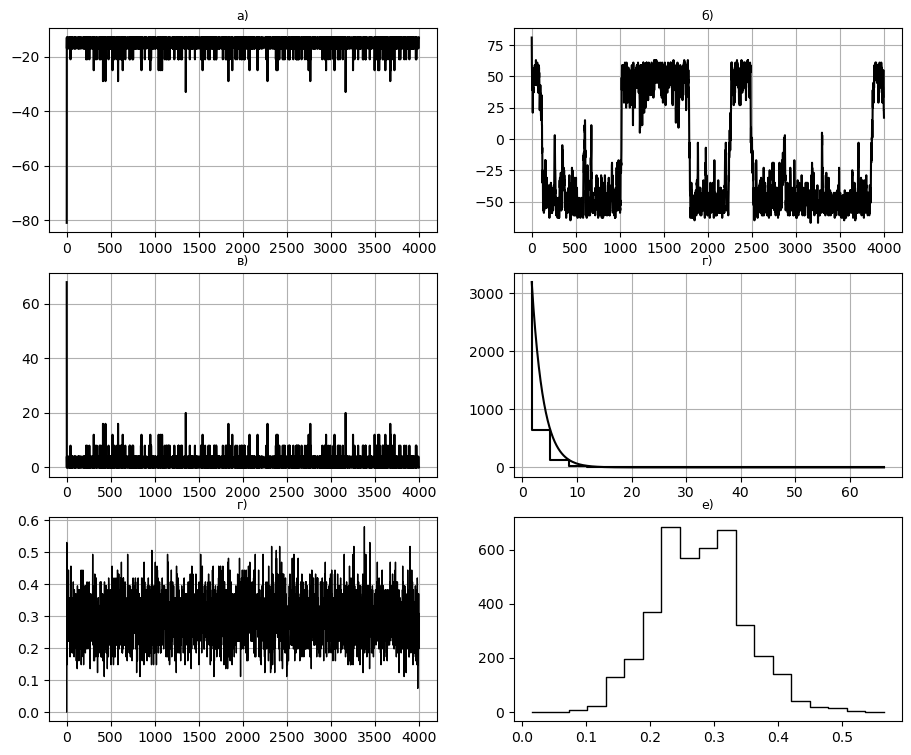

T =  2.531786796926503


In [ ]:
# Ячейка № 4

# визуализация случайных последовательностей,
# составленных из значений:
# энергии системы, энергии демона,
# суммарного магнитного момента системы спинов,
# числа принятых пробных переворотов спина,
# нормированного на число спинов

# вычисление последовательностей,
# составленных из мгновенных значений
#  энергий системы спинов,
# демона, суммарного магнитного момента
# системы спинов
fig = plt.figure(figsize=(11, 9))

# визуализация последовательности,
# составленной из мгновенных значений
# энергии системы
ax = plt.subplot(3, 2, 1)
plt.plot(E_System, color="black")
plt.grid(True)
ax.set_title("а)", fontsize=9)

# визуализация последовательностей,
# составленной из мгновенных значений
# полного магнитного момента системы спинов
ax = plt.subplot(3, 2, 2)
plt.plot(Summary_Spin_Moment, color="black")
plt.grid(True)
ax.set_title("б)", fontsize=9)

# визуализация последовательности,
# составленной из мгновенных значений
# энергии демона
ax = plt.subplot(3, 2, 3)
plt.plot(E_Demon, color="black")
plt.grid(True)
ax.set_title("в)", fontsize=9)

# визуализация эмпирической плотности распределения
# последовательности, составленной из мгновенных значений
# энергии системы остатков аппроксимации
ax = plt.subplot(3, 2, 4)

# вычисление и визуализация
# эмпирической плотности распределения
# последовательности, составленной
# из мгновенных значений энергии демона,
# и аппроксимации ее эмпирической плотности распределения
N_bin = 20
xbins = np.arange(
    np.min(E_Demon), np.max(E_Demon), (max(E_Demon) - min(E_Demon)) / N_bin
)

# вычисление эмпирической
# плотности распределения
# энергии демона
H = np.histogram(E_Demon, bins=20)

# вычисление координат
# центров интервалов гистограммы
x = np.zeros(len(H[1]) - 1)
for i in range(len(H[1]) - 1):
    x[i] = (H[1][i] + H[1][i + 1]) / 2

# вычисление коэффициентов a, b, c
# аппроксимации эмпирической
# плотности распределения
# мгновенной  энергии демона
# функцией вида a * sqrt(-b * x)
Coeff = curve_fit(lambda t, a, b: a * np.exp(-b * t), x, H[0], bounds=(0, [20000, 1]))
Сoeff2 = Coeff[0]


# задание функции, возвращающей
# значения аппроксимирующей функции
def func(x, a, b):
    return a * np.exp(-b * x)


# вычисление значений аппроксимирующей функции
x2 = np.linspace(x[0], x[len(x) - 1], 200)
y = func(x2, Сoeff2[0], Сoeff2[1])

# визуализация эмпирической плотности распределения
# и ее аппроксимации функцией вида a * sqrt(-b * x)
ax = plt.subplot(3, 2, 4)
plt.step(x, H[0], color="black")
plt.plot(x2, y, "-k")
plt.grid(True)
ax.set_title("г)", fontsize=9)

# визуализация последовательности,
# составленной из мгновенных значений
# числа принятых поворотов выбранного спина
ax = plt.subplot(3, 2, 5)
plt.plot(Accept, "-k", lw=1)
plt.grid(True)
ax.set_title("г)", fontsize=9)

ax = plt.subplot(3, 2, 6)
# вычисление и визуализация
# эмпирической плотности распределения
# последовательности, составленной
# из мгновенных значений числа принятых поворотов
# выбранного спина
N_bin = 20
xbins = np.arange(np.min(Accept), np.max(Accept), (max(Accept) - min(Accept)) / N_bin)

# вычисление эмпирической
# плотности распределения
# энергии демона
H = np.histogram(Accept, bins=20)

# вычисление координат
# центров интервалов гистограммы
x = np.zeros(len(H[1]) - 1)
for i in range(len(H[1]) - 1):
    x[i] = (H[1][i] + H[1][i + 1]) / 2

plt.step(x, H[0], "-k", lw=1)
ax.set_title("e)", fontsize=9)
plt.show()

# вычисление температуры системы
T = 4 / np.log(1 + 4 / np.mean(E_Demon))

print("T = ", T)

In [5]:
np.mean(E_Demon)

1.0377405648587854

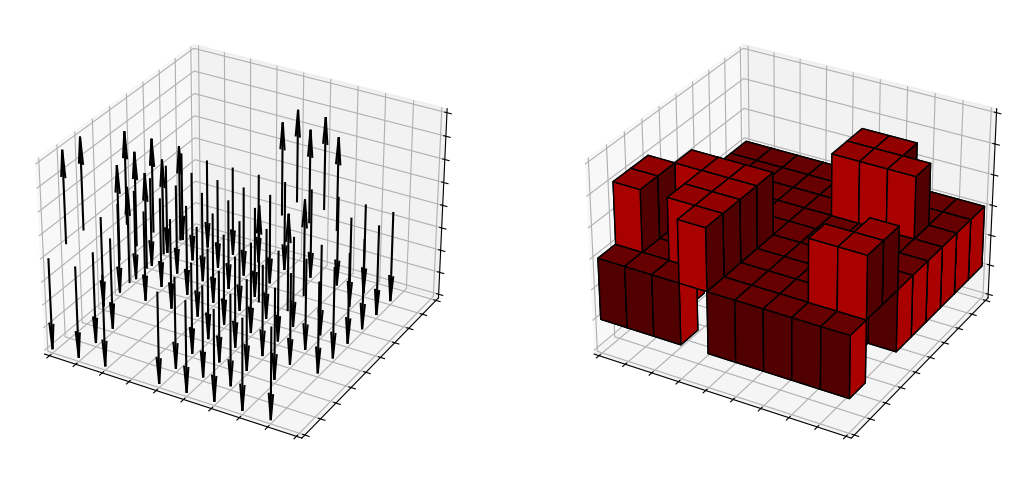

In [ ]:
# Ячейка № 4

# визуализация конфигурации спинов,
# соответствующей выбранному номеру
# шага метода Монте-Карло

# задание номера шага метода Монте-Карло
Number_Step_MK = 1000

# создание в узлах использованной
# координатной сетки единичных векторов,
# сонаправленных с соответствующими спинами
soa = np.zeros([N_x * N_y, 6])
k = 0
for i in range(N_x):
    for j in range(N_y):
        soa[k][0] = i
        soa[k][1] = j
        soa[k][5] = s[i, j, Number_Step_MK]
        k = k + 1
X, Y, Z, U, V, W = zip(*soa)

# визуализация мгновенной
# конфигурации спинов
# набора единичных векторов
fig = plt.figure(figsize=(13, 11))
ax = fig.add_subplot(121, projection="3d")
ax.quiver(X, Y, Z, U, V, W, color="black")
ax.set_xlim([0, N_x])
ax.set_ylim([0, N_y])
ax.set_zlim([-1, 1])

ax.set(xticklabels=[], yticklabels=[], zticklabels=[])
plt.style.use("_mpl-gallery")
ax = fig.add_subplot(122, projection="3d")

# визуализация мгновенной
# конфигурации спинов
# набора параллелепипедов, расположенных
# вдоль оси OZ в соответствии с ориентацией спинов

for i in range(N_x):
    for j in range(N_y):
        x = i
        y = j
        z = 0
        dx = 1
        dy = 1
        dz = s[i, j, Number_Step_MK]
        ax.bar3d(x, y, z, dx, dy, dz, alpha=1, color=(0.75, 0, 0, 0), edgecolor="black")
ax.set_xlim([0, N_x])
ax.set_ylim([0, N_y])
ax.set_zlim([-1.5, 1.5])
ax.set(xticklabels=[], yticklabels=[], zticklabels=[])

plt.show()